In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('/Users/alexren/Documents/sentiment_analysis_dataset.csv')

In [3]:
data.head()

,statement,status
0,oh my gosh,anxiety
1,trouble sleeping confused mind restless heart ...,anxiety
2,all wrong back off dear forward doubt stay in ...,anxiety
3,ive shifted my focus to something else but im ...,anxiety
4,im restless and restless its been a month now ...,anxiety


In [4]:
data.shape

(52681, 2)

In [5]:
data['status'].value_counts()

status
normal                  16343
depression              15404
suicidal                10652
anxiety                  3841
bipolar                  2777
stress                   2587
personality disorder     1077
Name: count, dtype: int64

In [6]:
percentages = {}

for status in data['status'].unique():
    percentages[status] = len(data[data['status'] == status]) / data.shape[0]

percentages_df = pd.DataFrame(list(percentages.items()), columns=['Status', 'Proportion'])

percentages_df

,Status,Proportion
0,anxiety,0.072911
1,normal,0.310226
2,depression,0.292401
3,suicidal,0.202198
4,stress,0.049107
5,bipolar,0.052714
6,personality disorder,0.020444


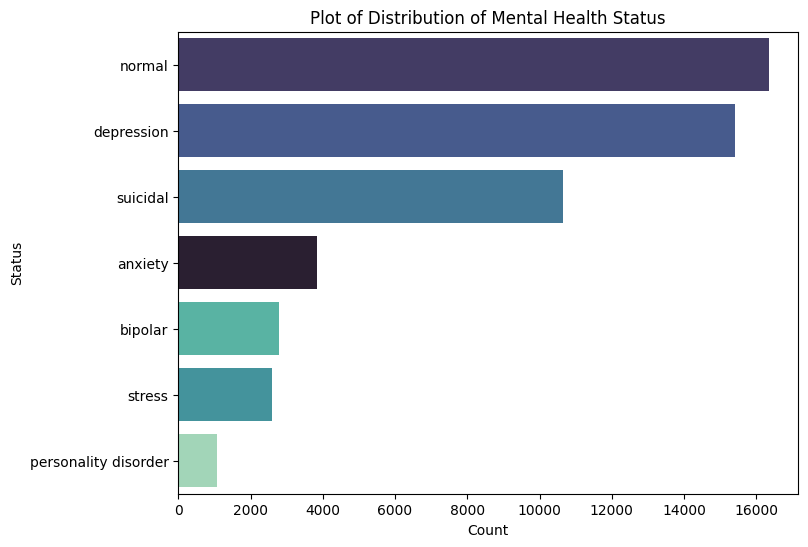

In [7]:
plt.figure(figsize=(8, 6))
sns.countplot(
    data = data,
    y = 'status',
    order = data['status'].value_counts().index,
    hue = 'status',
    palette = 'mako'
)
plt.title('Plot of Distribution of Mental Health Status')
plt.xlabel('Count')
plt.ylabel('Status')
plt.show()

As we can see, from the above plot of class distributions, the most top 3 common mental statuses are normal, depression, and suicidal. It is quite concerning that suicidal is in the top 3 most common, since a large proportion of people need serious mental help. Additionally, the plot shows that class distribution is very uneven.

In [8]:
def split_txt(text):
    lst = text.split()

    return lst

word_counts = []
char_counts = []

for text in data['statement']:
    word_count = len(split_txt(str(text)))
    word_counts.append(word_count)

    char_counts.append(len(str(text)))

data['Word Count'] = word_counts
data['Character Count'] = char_counts

data.head()



,statement,status,Word Count,Character Count
0,oh my gosh,anxiety,3,10
1,trouble sleeping confused mind restless heart ...,anxiety,10,61
2,all wrong back off dear forward doubt stay in ...,anxiety,14,75
3,ive shifted my focus to something else but im ...,anxiety,11,59
4,im restless and restless its been a month now ...,anxiety,14,66


/var/folders/b9/z9wybbyd3ydcghf9x081bk0c0000gn/T/ipykernel_55966/1513431709.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='status', y='Word Count', palette='mako')


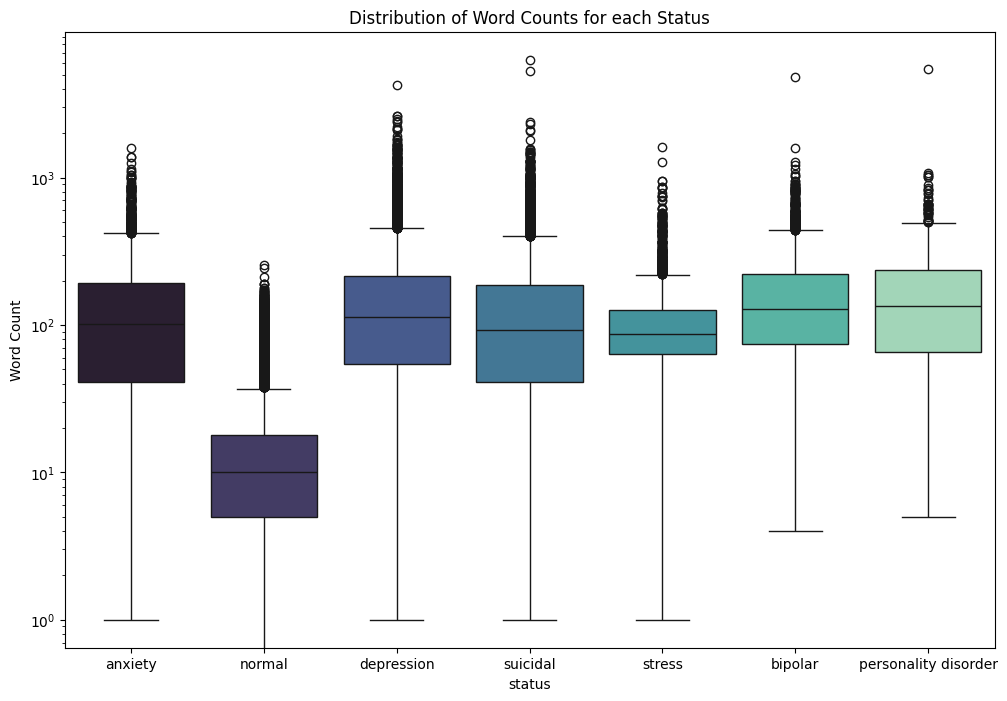

In [9]:
plt.figure(figsize=(12,8))
sns.boxplot(data=data, x='status', y='Word Count', palette='mako')
plt.yscale('log')
plt.title('Distribution of Word Counts for each Status')
plt.show()

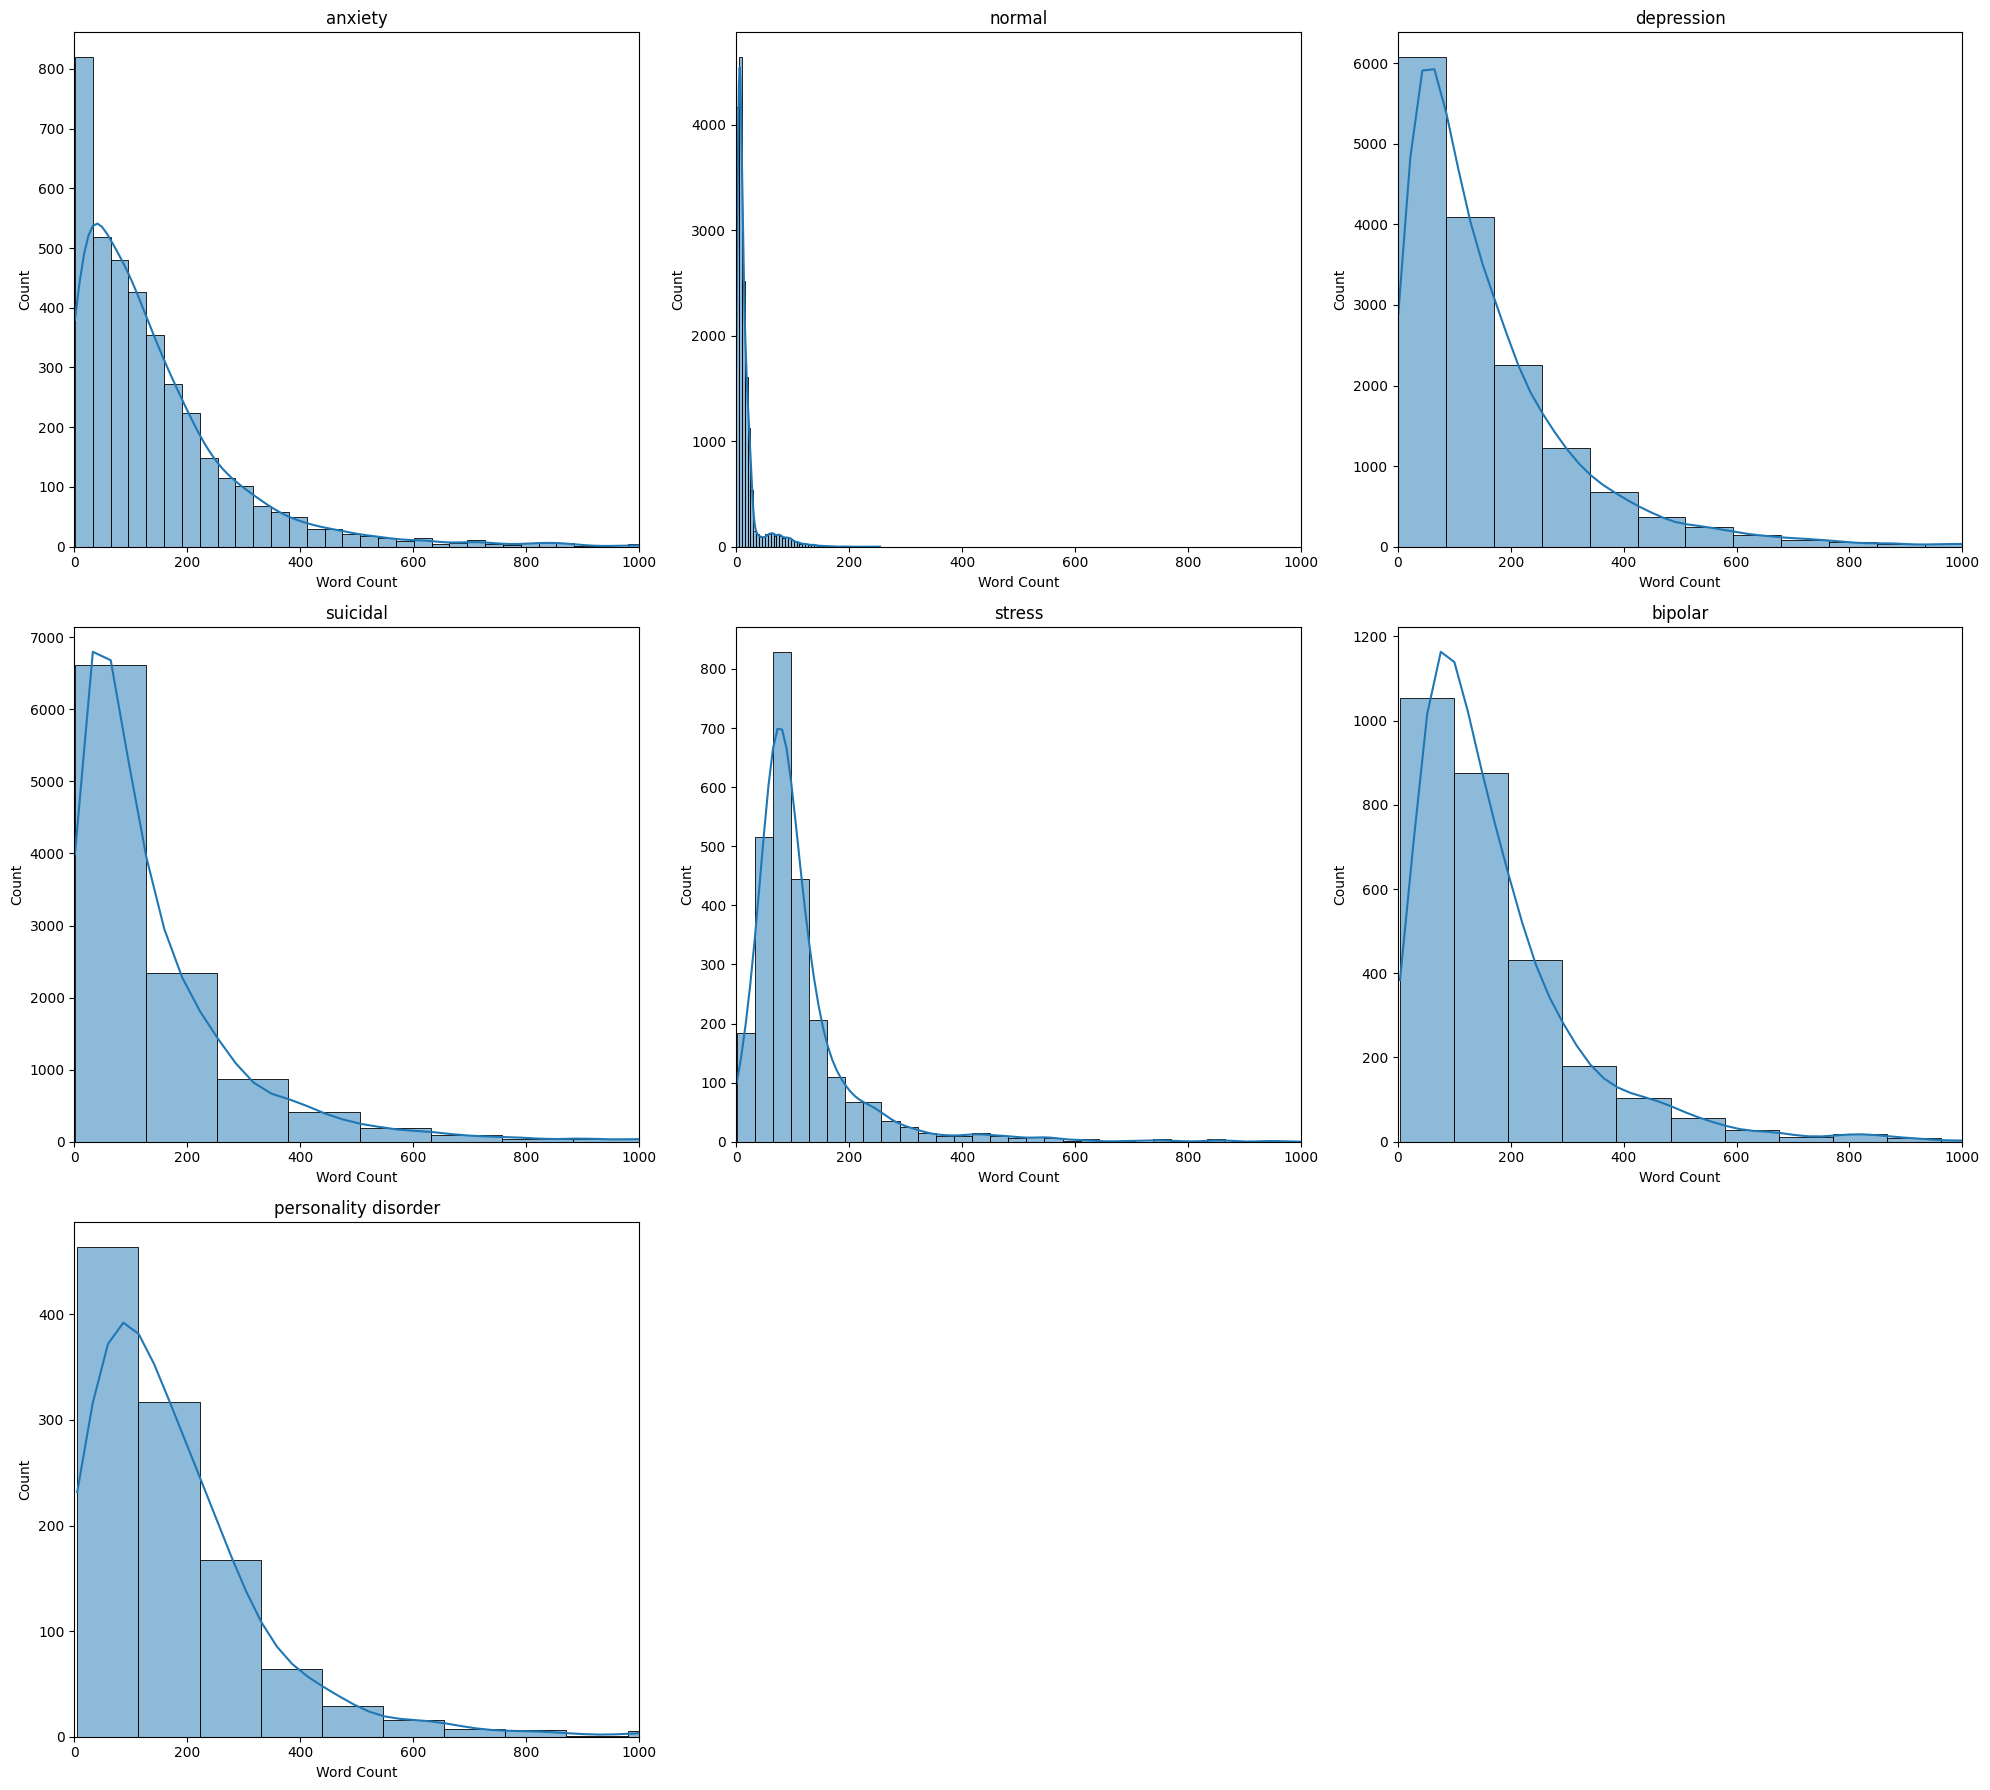

In [10]:
features_to_plot = data['status'].unique()

plt.figure(figsize=(20,18))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(3, 3, i)
    subset = data[data['status'] == feature]
    sns.histplot(subset['Word Count'], bins = 50, kde=True)
    plt.xlim(0, 1000)
    plt.title(feature)

plt.tight_layout()
plt.show()

/var/folders/b9/z9wybbyd3ydcghf9x081bk0c0000gn/T/ipykernel_55966/407845365.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='status', y='Character Count', palette='mako')


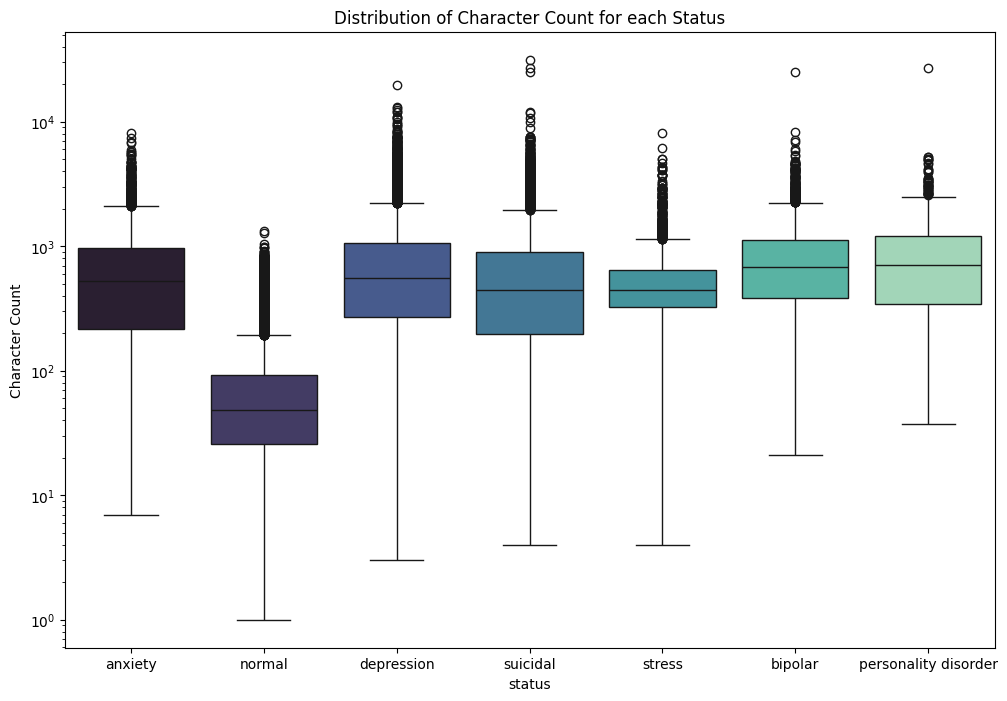

In [11]:
plt.figure(figsize=(12,8))
sns.boxplot(data=data, x='status', y='Character Count', palette='mako')
plt.yscale('log')
plt.title('Distribution of Character Count for each Status')
plt.show()

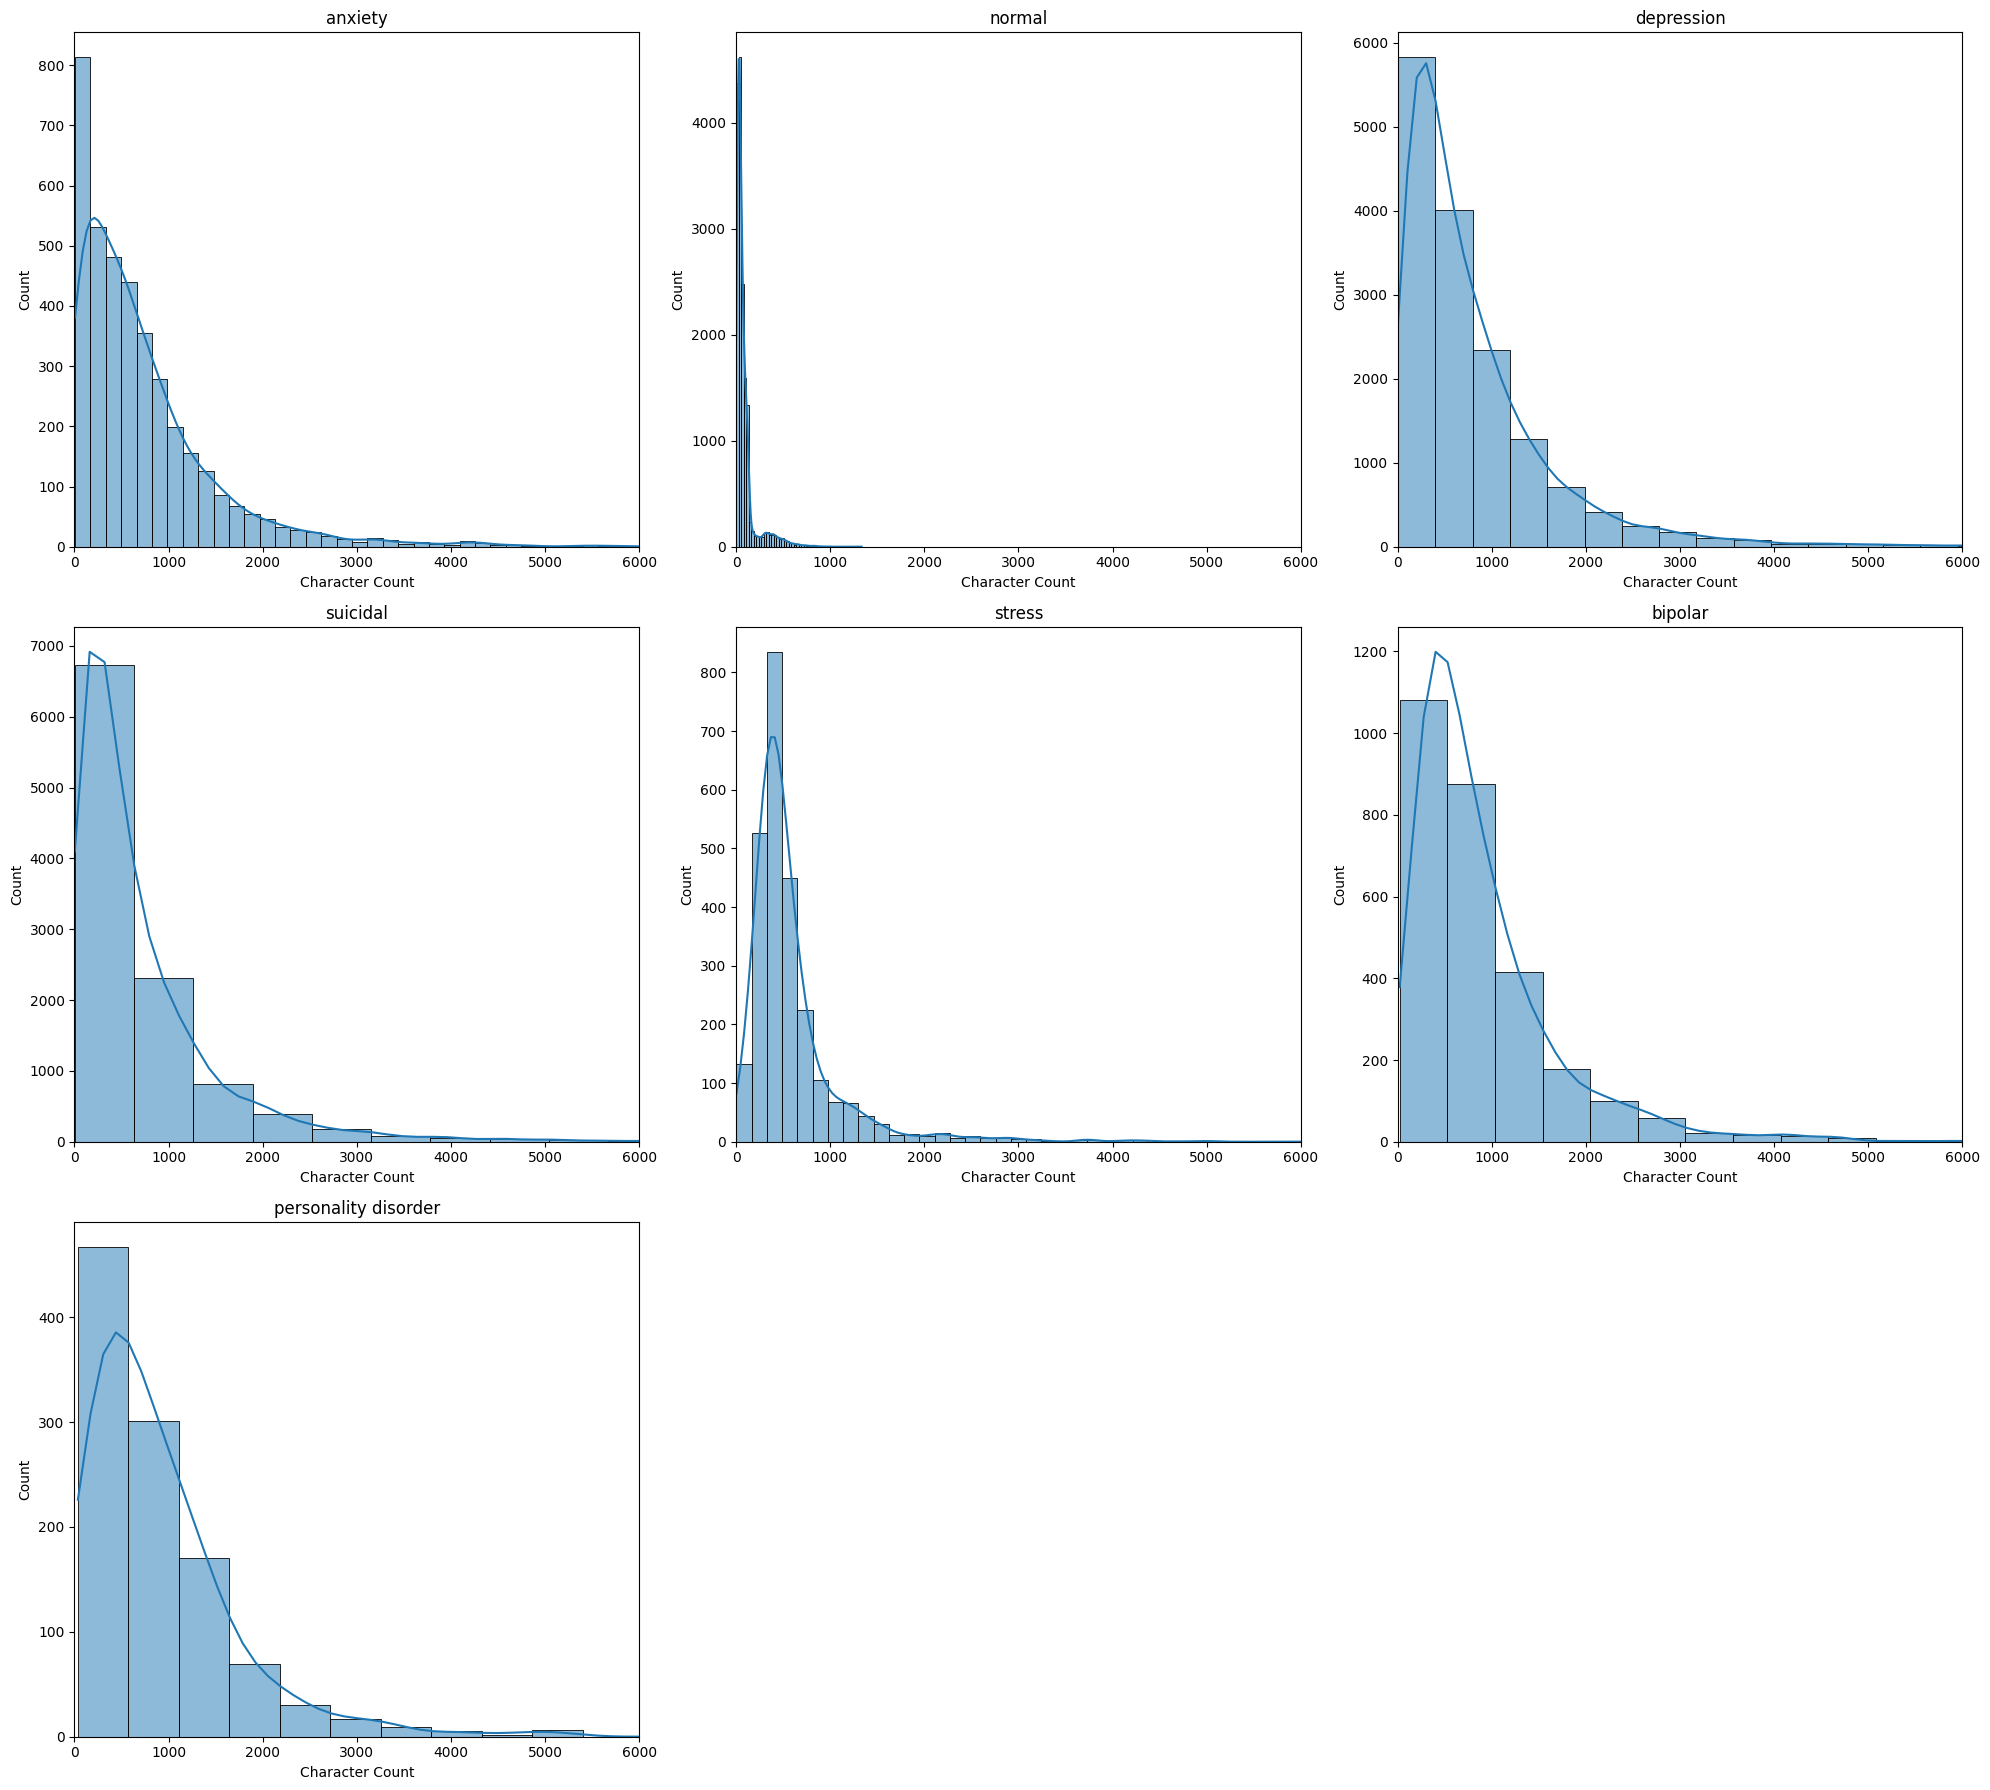

In [12]:
plt.figure(figsize=(20,18))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(3, 3, i)
    subset = data[data['status'] == feature]
    sns.histplot(subset['Character Count'], bins = 50, kde=True)
    plt.xlim(0, 6000)
    plt.title(feature)

plt.tight_layout()
plt.show()

In [13]:
# Summary Statistics of Word Count
print("Summary Statistics of Word Count")
summary_wc = data.groupby('status')['Word Count'].describe()
print(summary_wc, '\n')

# Summary Statistics of Character Count
print("Summary Statistics of Character Count")
summary_cc = data.groupby('status')['Character Count'].describe()
print(summary_cc)

Summary Statistics of Word Count
                        count        mean         std  min   25%    50%  \
status                                                                    
anxiety                3841.0  143.387139  152.198817  1.0  41.0  102.0   
bipolar                2777.0  175.775297  176.122094  4.0  74.0  129.0   
depression            15404.0  167.786938  188.023894  1.0  54.0  113.0   
normal                16343.0   17.100838   22.704211  0.0   5.0   10.0   
personality disorder   1077.0  178.896007  221.621547  5.0  66.0  135.0   
stress                 2587.0  114.080015  105.083097  1.0  64.0   87.0   
suicidal              10652.0  146.226812  186.789631  1.0  41.0   92.0   

                         75%     max  
status                                
anxiety               192.00  1580.0  
bipolar               220.00  4796.0  
depression            215.00  4239.0  
normal                 18.00   255.0  
personality disorder  236.00  5419.0  
stress            

- From the distribution plots and the summary statistics, it seems that on average, those in the bipolar, depression, and personality disorders seem to write significantly more words and characters in their texts compared to those of other categories.
- Also, it seems that the data for the classes, as indicated by the boxplots and histograms are, are very skewed to the right
- The normal class consistently have the lowest mean and median word and character counts

In [14]:
# Next Steps: Plots of Most Commonly used Words

common_words_dict = {}

for status in data['status'].unique():
    most_common_words = data[data['status'] == status]['statement'].str.lower().str.split().explode().value_counts()

    top_50_words = most_common_words.iloc[0:50].index.tolist()

    common_words_dict[status] = top_50_words

common_words_df = pd.DataFrame(common_words_dict)
common_words_df

,anxiety,normal,depression,suicidal,stress,bipolar,personality disorder
0,i,i,i,i,i,i,i
1,and,to,to,to,and,and,to
2,to,the,and,and,to,to,and
3,the,a,the,my,the,the,the
4,a,and,my,the,a,a,a
5,my,you,a,not,my,my,my
6,of,it,it,a,of,of,of
7,it,is,not,am,me,it,me
8,that,my,of,it,it,im,that
9,im,of,me,is,in,in,it


/var/folders/b9/z9wybbyd3ydcghf9x081bk0c0000gn/T/ipykernel_55966/1273342580.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = top_20_words.values, y = top_20_words.index, palette = 'mako')
/var/folders/b9/z9wybbyd3ydcghf9x081bk0c0000gn/T/ipykernel_55966/1273342580.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = top_20_words.values, y = top_20_words.index, palette = 'mako')
/var/folders/b9/z9wybbyd3ydcghf9x081bk0c0000gn/T/ipykernel_55966/1273342580.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = top_20_words.values, y = 

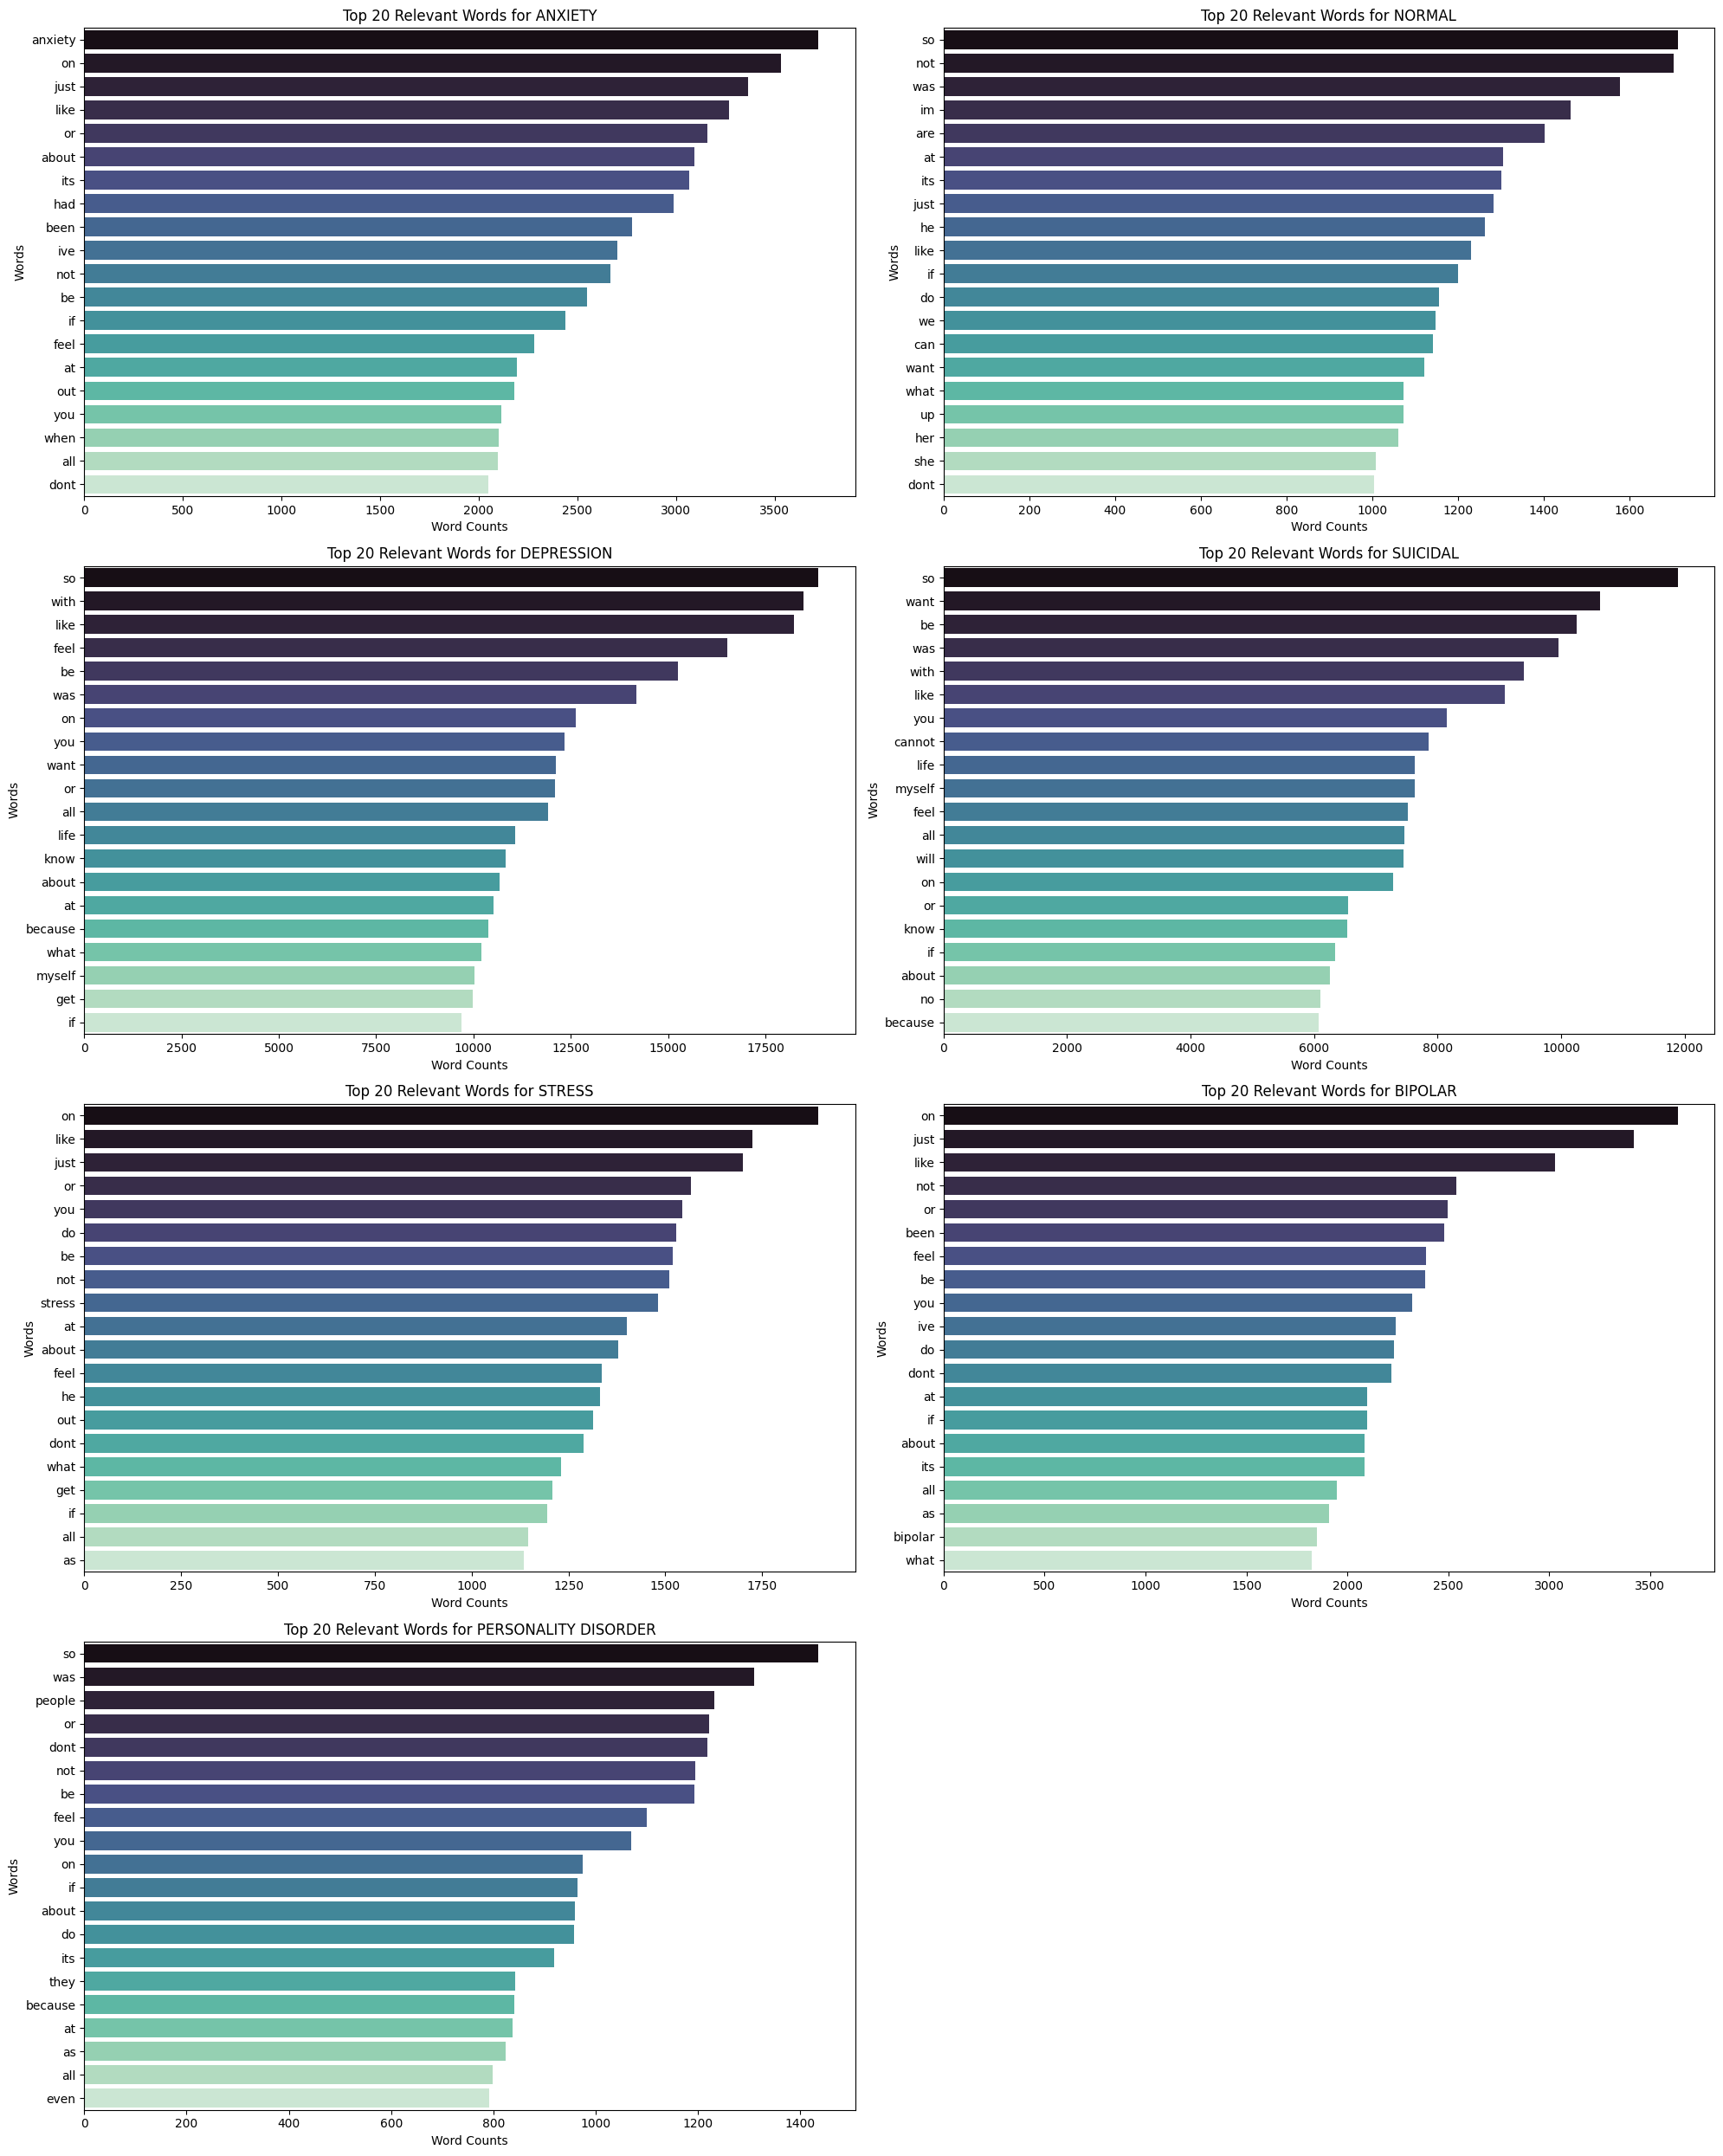

In [15]:
plt.figure(figsize=(20,25))
for i, status in enumerate(data['status'].unique(), 1):
    plt.subplot(4, 2, i)
    most_common_words = data[data['status'] == status]['statement'].str.lower().str.split().explode().value_counts()
    
    top_20_words = most_common_words.iloc[20:40]

    sns.barplot(x = top_20_words.values, y = top_20_words.index, palette = 'mako')

    plt.title(f"Top 20 Relevant Words for {status.upper()}")
    plt.xlabel("Word Counts")
    plt.ylabel("Words")
plt.tight_layout()

Possible Next Steps
- Clean out "filler" words
- Normalize the data with transformations due to skewness
- etc.

In [16]:
percentiles = [0.50, 0.75, 0.90, 0.95, 0.99]
stats = data['Word Count'].describe(percentiles=percentiles)
stats

count    52681.000000
mean       112.912644
std        163.515119
min          0.000000
50%         62.000000
75%        148.000000
90%        278.000000
95%        395.000000
99%        732.000000
max       6300.000000
Name: Word Count, dtype: float64